# P1 프로젝트: 의류 이미지 분류

MNIST 실습에서는 기본 신경망을 구성하고 훈련하는 전체 과정을 Keras와 PyTorch로 확인했다.

이번 프로젝트에서는 같은 원리를 **Fashion-MNIST 의류 이미지 분류 문제**에 적용한다.

프로젝트의 목표는 실습 코드를 그대로 반복하는 것이 아니라,

> **문제를 이해하고 → 모델을 구성하고 → 결과를 비교하고 → 오류를 분석하여 → 최종 판단을 내리는 것**

이다.

Keras와 PyTorch 중 **하나의 프레임워크를 선택**하여 프로젝트를 진행한다.

**코드 실행**

[(구글 코랩) P1 프로젝트: 다층 퍼셉트론](https://colab.research.google.com/github/codingalzi/code-workout-dlp/blob/master/P1_project_fashion_mnist.ipynb)에서 코드를 실행할 수 있다.

## 프로젝트에서 해야 할 일

1. Fashion-MNIST 데이터와 타깃의 의미를 확인한다.
2. 이미지를 완전연결 신경망에 맞게 변환하고 정규화한다.
3. MNIST 실습의 기본 신경망을 출발점으로 **기준 모델**을 만든다.
4. 기준 모델에서 구조를 하나 이상 변경한 **비교 모델**을 만든다.
5. 두 모델의 훈련 결과와 검증 결과를 비교한다.
6. 선택한 모델을 테스트 데이터에서 최종 평가한다.
7. 오분류 사례를 살펴보고 모델이 어려워하는 경우를 분석한다.
8. 모델 선택의 근거와 한계를 정리한다.

> **성능 수치 하나만 높이는 것이 목표가 아니다. 왜 그 모델을 선택했는지 설명할 수 있어야 한다.**

## 생성형 AI 활용

생성형 AI는 코드 작성·수정, 오류 메시지 해석, Keras와 PyTorch 코드 변환, 그래프 작성, 분석 아이디어 제안 등에 활용할 수 있다.

다만 **입력과 타깃의 의미, 모델 구조, 비교 조건, 결과 해석, 오분류 분석, 최종 모델 선택**은 직접 확인하고 판단해야 한다.

프로젝트 마지막에 **AI를 어디에 활용했고 무엇을 직접 검증했는지** 기록한다.

---

## 실행 환경 확인

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import keras
import torch

tf_gpus = tf.config.list_physical_devices("GPU")

print("=== TensorFlow ===")
print("Version:", tf.__version__)
print("GPU 사용 가능:", len(tf_gpus) > 0)
if tf_gpus:
    print("GPU:", tf_gpus[0].name)

print()

print("=== PyTorch ===")
print("Version:", torch.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

=== TensorFlow ===
Version: 2.20.0
GPU 사용 가능: True
GPU: /physical_device:GPU:0

=== PyTorch ===
Version: 2.11.0+cu128
GPU 사용 가능: True
GPU: Tesla T4
CUDA version: 12.8


---

## Fashion-MNIST 데이터

Fashion-MNIST는 10종류의 의류 이미지로 구성된 데이터셋이다. 각 이미지는 MNIST와 마찬가지로 `28 × 28` 크기의 흑백 이미지다.

| label | class |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

In [2]:
from keras.datasets import fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images :", test_images.shape)
print("test_labels :", test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train_images: (60000, 28, 28)
train_labels: (60000,)
test_images : (10000, 28, 28)
test_labels : (10000,)


### 데이터 구조 설명

다음 질문에 답하라.

1. `train_images.shape`의 각 숫자는 무엇을 의미하는가?
2. `train_labels.shape`은 무엇을 의미하는가?
3. MNIST와 Fashion-MNIST의 입력 데이터 구조에서 공통점은 무엇인가?
4. 두 데이터셋의 **예측 대상**은 어떻게 다른가?

**답:**

> 여기에 설명을 작성한다.

## 실제 이미지 확인

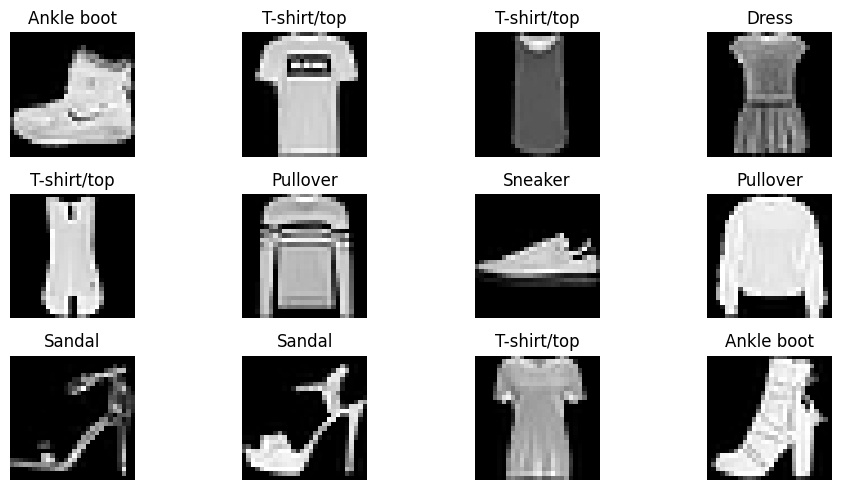

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))
for i in range(12):
    ax = fig.add_subplot(3, 4, i + 1)
    ax.imshow(train_images[i], cmap="gray")
    ax.set_title(class_names[train_labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

### 관찰

- 사람이 보기에 쉽게 구분되는 클래스는 무엇인가?
- 서로 비슷해 보여 혼동될 가능성이 있는 클래스는 무엇인가?
- 그 이유는 무엇이라고 생각하는가?

**답:**

> 여기에 관찰 결과를 작성한다.

## 입력 데이터 준비

MNIST 실습과 같은 방식으로 이미지를 완전연결층에 맞게 펼치고 픽셀값을 `0~1` 범위로 정규화한다.

> `(28, 28) → (784,)`

In [4]:
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

print("train_images:", train_images.shape)
print("test_images :", test_images.shape)
print("픽셀값 범위:", train_images.min(), "~", train_images.max())

train_images: (60000, 784)
test_images : (10000, 784)
픽셀값 범위: 0.0 ~ 1.0


### 전처리 확인

1. reshape 전후에 이미지 한 장의 픽셀 수는 달라졌는가?
2. 왜 완전연결 신경망에서는 이미지를 `(784,)`로 펼쳐 사용하는가?
3. 픽셀값을 `0~1` 범위로 바꾼 이유는 무엇인가?

**답:**

> 여기에 설명을 작성한다.

---

## 모델링

Keras 또는 PyTorch 중 하나를 선택한다.

MNIST 실습에서 사용한

> **784 → 512 → 10**

구조를 기준 모델의 출발점으로 사용하고, 비교 모델에서는 다음 중 하나 이상을 바꿀 수 있다.

- 은닉 유닛 수
- 은닉층 수
- 배치 크기
- 에포크 수

여러 항목을 동시에 크게 바꾸기보다 **무엇을 바꾸었는지 설명할 수 있도록 비교 조건을 단순하게 유지**한다.

> Dropout, Early Stopping 등의 규제 기법은 P2에서 다룬다. P1에서는 사용하지 않는다.

### 선택한 프레임워크

- 선택: **Keras / PyTorch**
- 선택 이유:

> 여기에 작성한다.

---

## Keras를 선택한 경우

PyTorch를 선택했다면 이 절은 실행하지 않아도 된다.

### Keras 기준 모델

In [5]:
from keras import layers

keras_base = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

keras_base.build(input_shape=(None, 28 * 28))
keras_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
keras_base.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_base = keras_base.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8152 - loss: 0.5297 - val_accuracy: 0.8566 - val_loss: 0.4139
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8612 - loss: 0.3898 - val_accuracy: 0.8590 - val_loss: 0.3865
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8756 - loss: 0.3425 - val_accuracy: 0.8702 - val_loss: 0.3590
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8852 - loss: 0.3136 - val_accuracy: 0.8808 - val_loss: 0.3299
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8933 - loss: 0.2937 - val_accuracy: 0.8847 - val_loss: 0.3258


### Keras 비교 모델

새로운 다층 퍼셉트론을 정의하고 기준 모델에서 **무엇을 바꾸었는지와 그 이유**를 먼저 작성한다.

**변경 내용과 이유:**

> 여기에 작성한다.

In [7]:
# TODO: 비교 모델을 구성한다.
keras_compare = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# TODO: 입력 shape에 맞게 build하고 구조를 확인한다.
keras_compare.build(input_shape=(None, 28 * 28))
keras_compare.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# TODO: 비교 모델을 compile하고 훈련한다.
keras_compare.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_compare = keras_compare.fit(
     train_images,
     train_labels,
     epochs=5,
     batch_size=128,
     validation_split=0.2,

)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8216 - loss: 0.5062 - val_accuracy: 0.8542 - val_loss: 0.4063
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8653 - loss: 0.3707 - val_accuracy: 0.8745 - val_loss: 0.3510
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8796 - loss: 0.3277 - val_accuracy: 0.8723 - val_loss: 0.3471
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8889 - loss: 0.2992 - val_accuracy: 0.8727 - val_loss: 0.3435
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8937 - loss: 0.2831 - val_accuracy: 0.8852 - val_loss: 0.3171


---

## PyTorch를 선택한 경우

Keras를 선택했다면 이 절은 실행하지 않아도 된다.

### PyTorch 데이터 준비

In [9]:
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

x_train_t = torch.tensor(train_images, dtype=torch.float32)
y_train_t = torch.tensor(train_labels, dtype=torch.long)
x_test_t = torch.tensor(test_images, dtype=torch.float32)
y_test_t = torch.tensor(test_labels, dtype=torch.long)

full_train_dataset = TensorDataset(x_train_t, y_train_t)
test_dataset = TensorDataset(x_test_t, y_test_t)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator,
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print("train:", len(train_dataset))
print("validation:", len(val_dataset))
print("test:", len(test_dataset))

train: 48000
validation: 12000
test: 10000


### PyTorch 기준 모델

In [10]:
torch_base = nn.Sequential(
    nn.Linear(28 * 28, 512),
    nn.ReLU(),
    nn.Linear(512, 10),
)

torch_base

Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=10, bias=True)
)

### PyTorch 훈련 함수

프로젝트의 초점은 반복문의 문법이 아니라 **모델을 비교하고 결과를 판단하는 것**이므로 훈련 함수의 기본 틀을 제공한다.

In [11]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

def train_torch_model(model, train_loader, val_loader, epochs=5):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)
            correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(x_batch)
                loss = loss_fn(outputs, y_batch)

                val_running_loss += loss.item() * x_batch.size(0)
                val_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
                val_total += y_batch.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(
            f"epoch {epoch + 1}: "
            f"loss={train_loss:.4f}, accuracy={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_accuracy={val_acc:.4f}"
        )

    return model, history

In [12]:
torch_base, torch_history_base = train_torch_model(
    torch_base,
    train_loader,
    val_loader,
    epochs=5,
)

epoch 1: loss=0.5587, accuracy=0.8050, val_loss=0.4416, val_accuracy=0.8438
epoch 2: loss=0.4060, accuracy=0.8556, val_loss=0.3973, val_accuracy=0.8582
epoch 3: loss=0.3581, accuracy=0.8705, val_loss=0.3726, val_accuracy=0.8642
epoch 4: loss=0.3272, accuracy=0.8810, val_loss=0.3329, val_accuracy=0.8818
epoch 5: loss=0.3051, accuracy=0.8896, val_loss=0.3424, val_accuracy=0.8742


### PyTorch 비교 모델

**변경 내용과 이유:**

> 여기에 작성한다.

In [15]:
torch_compare = nn.Sequential(
    nn.Linear(28 * 28, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10),

)

# TODO: 비교 모델을 훈련한다.
torch_compare, torch_history_compare = train_torch_model(
     torch_compare,
     train_loader,
     val_loader,
     epochs=5
)

epoch 1: loss=0.5560, accuracy=0.8008, val_loss=0.4204, val_accuracy=0.8450
epoch 2: loss=0.3808, accuracy=0.8615, val_loss=0.3625, val_accuracy=0.8681
epoch 3: loss=0.3392, accuracy=0.8756, val_loss=0.3437, val_accuracy=0.8767
epoch 4: loss=0.3114, accuracy=0.8860, val_loss=0.3230, val_accuracy=0.8841
epoch 5: loss=0.2917, accuracy=0.8917, val_loss=0.3252, val_accuracy=0.8831


---

## 모델 비교

선택한 프레임워크에서 **기준 모델과 비교 모델의 훈련·검증 결과**를 비교한다.

In [ ]:
# TODO: 선택한 프레임워크에 맞게 history를 지정한다.
#
# Keras:
base_history = history_base.history
compare_history = history_compare.history
#
# PyTorch:
# base_history = torch_history_base
# compare_history = torch_history_compare

In [ ]:
# TODO: 두 모델의 검증 정확도를 비교한다.
#
# plt.figure(figsize=(7, 4))
# plt.plot(base_history["val_accuracy"], marker="o", label="base")
# plt.plot(compare_history["val_accuracy"], marker="o", label="compare")
# plt.xlabel("epoch")
# plt.ylabel("validation accuracy")
# plt.legend()
# plt.show()

### 결과 비교와 모델 선택

1. 기준 모델과 비교 모델에서 무엇을 다르게 했는가?
2. 훈련 정확도는 어떻게 달라졌는가?
3. 검증 정확도와 검증 loss는 어떻게 달라졌는가?
4. 단순히 마지막 에포크의 정확도만 보고 모델을 선택해도 되는가?
5. 두 모델 중 하나를 최종 모델로 선택한다면 무엇을 선택하겠는가?
6. 그 이유는 무엇인가?

**답:**

> 여기에 비교와 판단을 작성한다.

---

## 최종 테스트 평가

모델 비교가 끝난 뒤 **선택한 최종 모델 하나만** 테스트 데이터에서 평가한다.

테스트 데이터는 모델 선택 과정에 사용하지 않는다.

In [16]:
# TODO: Keras를 선택한 경우
#
final_model = keras_base
test_loss, test_acc = final_model.evaluate(test_images, test_labels, verbose=0)
print(f"test loss     : {test_loss:.4f}")
print(f"test accuracy : {test_acc:.4f}")

test loss     : 0.3481
test accuracy : 0.8757


In [17]:
# TODO: PyTorch를 선택한 경우
#
# final_model = ...
# final_model.eval()
# correct = 0
# total = 0
#
# with torch.no_grad():
#     for x_batch, y_batch in test_loader:
#         x_batch = x_batch.to(device)
#         y_batch = y_batch.to(device)
#         outputs = final_model(x_batch)
#         predictions_t = outputs.argmax(dim=1)
#         correct += (predictions_t == y_batch).sum().item()
#         total += y_batch.size(0)
#
# test_acc = correct / total
# print(f"test accuracy: {test_acc:.4f}")

### 테스트 결과 해석

- 테스트 정확도:
- 검증 정확도와 테스트 정확도의 차이:
- 이 결과만으로 모델이 충분히 좋다고 말할 수 있는가?

**답:**

> 여기에 작성한다.

---

## 프로젝트 최종 정리

### 문제와 데이터
> 무엇을 예측했고 입력과 타깃은 무엇이었는가?

### 모델 비교
> 기준 모델과 비교 모델의 차이는 무엇이었는가?

### 최종 모델 선택
> 어떤 모델을 선택했고 그 근거는 무엇인가?

### 오류와 한계
> 어떤 오류가 눈에 띄었고 현재 모델의 한계는 무엇이라고 판단하는가?

### 개선 아이디어
> 다음에 모델을 개선한다면 무엇을 시도해보고 싶은가?

### 생성형 AI 활용과 검증
> AI를 어디에 사용했으며, AI의 제안이나 코드를 무엇을 기준으로 직접 확인했는가?

## 제출 전 확인

- [ ] Fashion-MNIST 데이터와 타깃의 의미를 설명했다.
- [ ] 기준 모델을 훈련했다.
- [ ] 기준 모델과 다른 비교 모델을 하나 이상 만들었다.
- [ ] 변경한 내용과 이유를 설명했다.
- [ ] 훈련 결과와 검증 결과를 비교했다.
- [ ] 최종 모델을 선택하고 선택 근거를 설명했다.
- [ ] 테스트 데이터에서 최종 성능을 확인했다.
- [ ] 모델의 한계와 개선 아이디어를 제시했다.
- [ ] 생성형 AI 활용 내용과 직접 검증한 내용을 기록했다.